## Importamos las Librerías:

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from imblearn.over_sampling import SMOTE

## Establecemos los Parámetros de los Gráficos:

In [3]:
sns.set_style("white")
sns.set_context("notebook")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

## Cargamos el Conjunto de Datos:

In [4]:
data = pd.read_csv('~/homicidios/data/final/homicidios_final.csv')
data

,ent_regis,ent_resid,tloc_ocurr,causa_def,cod_adicio,lista_mex,sexo,afromex,conindig,lengua,...,area_ur,edad_agru,complicaro,dia_cert,mes_cert,anio_cert,maternas,razon_m,estado_defuncion_registrada,estado_defuncion_residencia
0,1,32,500 000 a 999 999 habitantes,"Neumonía, no especificada",NaN,Neumonía,Mujer,No,No,No,...,Urbana,De 70 a 74 años,No especificada,Dieciocho días,Diciembre,2022,NaN,NaN,Aguascalientes,Zacatecas
1,1,1,500 000 a 999 999 habitantes,Síndrome de dificultad respiratoria del adulto,NaN,Las demás enfermedades del aparato respiratorio,Mujer,No,No,No,...,Urbana,De 75 a 79 años,No especificada,Doce días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
2,1,1,500 000 a 999 999 habitantes,Enfermedad pulmonar obstructiva crónica con in...,NaN,Enfermedades pulmonares obstructivas crónicas,Mujer,No,No,No,...,Urbana,De 65 a 69 años,No especificada,Diecisiete días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
3,1,1,500 000 a 999 999 habitantes,Desnutrición proteicocalórica leve,NaN,Otras desnutriciones proteinocalóricas,Mujer,No,No,No,...,Urbana,De 90 a 94 años,No especificada,Un día,Enero,2023,NaN,NaN,Aguascalientes,Aguascalientes
4,1,14,500 000 a 999 999 habitantes,Cirrosis hepática alcohólica,NaN,Enfermedad alcohólica del hígado,Hombre,No,No,No,...,Rural,De 45 a 49 años,No aplica,Veintidós días,Diciembre,2022,NaN,NaN,Aguascalientes,Jalisco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799864,32,32,20 000 a 29 999 habitantes,"Síndrome de aspiración neonatal, sin otra espe...",NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,No especificado,Diciembre,2023,NaN,NaN,Zacatecas,Zacatecas
799865,32,32,100 000 a 249 999 habitantes,"Kernicterus, no especificado",NaN,Las demás afecciones originadas en el período ...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Cinco días,Junio,2023,NaN,NaN,Zacatecas,Zacatecas
799866,32,32,100 000 a 249 999 habitantes,Síndrome de dificultad respiratoria del recién...,NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Nueve días,Agosto,2023,NaN,NaN,Zacatecas,Zacatecas
799867,32,32,100 000 a 249 999 habitantes,Gastrosquisis,NaN,Otras malformaciones congénitas y deformidades...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Diecinueve días,Septiembre,2023,NaN,NaN,Zacatecas,Zacatecas


## Enraizamos el Proyecto:

In [5]:
import sys, os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

## Importamos las Funciones Modulares:

In [6]:
import modules.sustituir_nulos
from modules.sustituir_nulos import sustituir_nulos_pd
from modules.eliminar_variables import eliminar_variables_pd
from modules.eliminar_variables import variables_ml

In [7]:
data = eliminar_variables_pd(df= data, variables= variables_ml)

In [8]:
data.shape

(799869, 48)

## Sustituimos Valores Nulos:

In [9]:
data = sustituir_nulos_pd(df= data, variable= 'lista_mex', text= 'Sin Registros')
data = sustituir_nulos_pd(df= data, variable= 'estado_defuncion_residencia', text= 'Sin Registros')

## Corroboramos Ausencia de Valores Nulos:

In [10]:
data.isnull().sum().sort_values(ascending=False).head(10)

tloc_ocurr    0
causa_def     0
lista_mex     0
sexo          0
afromex       0
conindig      0
lengua        0
cve_lengua    0
nacionalid    0
nacesp_cve    0
dtype: int64

## Reducimos el Conjunto de Datos:

In [11]:
data['tipo_defun'].value_counts()

tipo_defun
Enfermedad (Muerte natural)        715751
Accidente                           40282
Homicidio (Agresión)                32253
Suicidio (Lesión autoinfligida)      9072
Se ignora                            2482
Intervención legale                    29
Name: count, dtype: int64

In [12]:
data = data[data['tipo_defun']=='Suicidio (Lesión autoinfligida)']

In [13]:
data['causa_def'].value_counts()

causa_def
Lesión autoinfligida intencionalmente por ahorcamiento, estrangulamiento o sofocación en vivienda                                                                       5307
Lesión autoinfligida intencionalmente por ahorcamiento, estrangulamiento o sofocación en lugar no especificado                                                          1043
Lesión autoinfligida intencionalmente por ahorcamiento, estrangulamiento o sofocación en otro lugar especificado                                                         669
Lesión autoinfligida intencionalmente por ahorcamiento, estrangulamiento o sofocación en calles y carreteras                                                             372
Lesión autoinfligida intencionalmente por disparo de otras armas de fuego, y las no especificadas en vivienda                                                            286
                                                                                                                             

## Creamos la Variable Clasificadora:

In [14]:
data['homsuici'] = ['Sí' if tipo_defun == 'Suicidio (Lesión autoinfligida)' and sexo == 'Hombre' else 'No' 
                          for tipo_defun, sexo in zip(data['tipo_defun'], data['sexo'])]

data

,tloc_ocurr,causa_def,lista_mex,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,...,minutos,capitulo,lista1,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,homsuici
620,1 a 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Cero minutos,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Rural,De 25 a 29 años,Doce días,Marzo,Aguascalientes,Aguascalientes,Sí
732,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Treinta minutos,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Rural,De 30 a 34 años,Quince días,Enero,Aguascalientes,Aguascalientes,No
791,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Cero minutos,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Urbana,De 15 a 19 años,Veintiséis días,Enero,Aguascalientes,Aguascalientes,Sí
793,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Treinta minutos,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Urbana,De 30 a 34 años,Siete días,Febrero,Aguascalientes,Aguascalientes,No
798,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Cero minutos,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Urbana,De 20 a 24 años,Cuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799406,1 a 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Urbana,De 30 a 34 años,Diez días,Diciembre,Zacatecas,Zacatecas,Sí
799418,1 a 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Rural,De 20 a 24 años,Diecinueve días,Diciembre,Zacatecas,Zacatecas,No
799419,100 000 a 249 999 habitantes,Lesión autoinfligida intencionalmente por disp...,Lesiones autoinfligidas intencionalmente,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Urbana,De 25 a 29 años,Veintinueve días,Noviembre,Zacatecas,Zacatecas,No
799459,10 000 a 14 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Lesiones autoinfligidas intencionalmente,Hombre,No,No,Se ignora,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Lesiones autoinfligidas intencionalmente,Urbana,De 25 a 29 años,Diez días,Diciembre,Zacatecas,Zacatecas,Sí


In [15]:
data = data.drop(['tipo_defun', 'lista_mex', 'lista1'], axis=1)
data

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,homsuici
620,1 a 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiséis años,...,Dos horas,Cero minutos,Factores suplementarios relacionados con causa...,Rural,De 25 a 29 años,Doce días,Marzo,Aguascalientes,Aguascalientes,Sí
732,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Treinta años,...,Diez horas,Treinta minutos,Factores suplementarios relacionados con causa...,Rural,De 30 a 34 años,Quince días,Enero,Aguascalientes,Aguascalientes,No
791,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Quince años,...,Tres horas,Cero minutos,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veintiséis días,Enero,Aguascalientes,Aguascalientes,Sí
793,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Treinta y cuatro años,...,Dieciocho horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 30 a 34 años,Siete días,Febrero,Aguascalientes,Aguascalientes,No
798,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintidós años,...,Tres horas,Cero minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Cuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799406,1 a 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Treinta y dos años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 30 a 34 años,Diez días,Diciembre,Zacatecas,Zacatecas,Sí
799418,1 a 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiún años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Rural,De 20 a 24 años,Diecinueve días,Diciembre,Zacatecas,Zacatecas,No
799419,100 000 a 249 999 habitantes,Lesión autoinfligida intencionalmente por disp...,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Veintinueve días,Noviembre,Zacatecas,Zacatecas,No
799459,10 000 a 14 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,Se ignora,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintisiete años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Diez días,Diciembre,Zacatecas,Zacatecas,Sí


## Convertimos a Numérica la Variable Objetivo:

In [16]:
data['homsuici'].replace(to_replace='Sí', value = 1, inplace=True)
data['homsuici'].replace(to_replace='No', value = 0, inplace=True)

In [17]:
data.head()

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,homsuici
620,1 a 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiséis años,...,Dos horas,Cero minutos,Factores suplementarios relacionados con causa...,Rural,De 25 a 29 años,Doce días,Marzo,Aguascalientes,Aguascalientes,1
732,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Treinta años,...,Diez horas,Treinta minutos,Factores suplementarios relacionados con causa...,Rural,De 30 a 34 años,Quince días,Enero,Aguascalientes,Aguascalientes,0
791,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Quince años,...,Tres horas,Cero minutos,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veintiséis días,Enero,Aguascalientes,Aguascalientes,1
793,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Treinta y cuatro años,...,Dieciocho horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 30 a 34 años,Siete días,Febrero,Aguascalientes,Aguascalientes,0
798,500 000 a 999 999 habitantes,Lesión autoinfligida intencionalmente por ahor...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintidós años,...,Tres horas,Cero minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Cuatro días,Marzo,Aguascalientes,Aguascalientes,1


In [18]:
data = data[data['sexo'] != 'No especificado']

In [19]:
data.shape

(9070, 46)

## === Reemplazar el undersampling por SMOTE ===:

In [20]:
X = data.drop('sexo', axis=1)
y = data['sexo']

## Codificar variables categóricas antes de aplicar SMOTE:

In [21]:
X = pd.get_dummies(X)

In [22]:
X

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,homsuici,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
620,12,3,15,3,2023,27,1997,1,False,False,...,False,False,False,False,False,False,False,False,False,False
732,15,1,18,1,2023,29,1992,0,False,False,...,False,False,False,False,False,False,False,False,False,False
791,26,1,99,1,2023,1,2007,1,False,False,...,False,False,False,False,False,False,False,False,False,False
793,7,2,13,2,2023,13,1988,0,False,False,...,False,False,False,False,False,False,False,False,False,False
798,4,3,10,3,2023,11,2000,1,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799406,99,11,12,12,2023,8,1991,1,False,False,...,False,False,False,False,False,False,False,False,False,True
799418,18,12,21,12,2023,2,2002,0,False,False,...,False,False,False,False,False,False,False,False,False,True
799419,28,11,1,12,2023,1,1995,0,False,False,...,False,False,False,False,False,False,False,False,False,True
799459,10,12,12,12,2023,5,1996,1,False,False,...,False,False,False,False,False,False,False,False,False,True


## Escalar antes de SMOTE (opcional pero recomendable si hay variables continuas):

In [23]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [24]:
X_scaled

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,homsuici,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
0,0.112245,0.020408,0.142857,0.181818,0.0,0.265306,0.009286,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.142857,0.000000,0.173469,0.000000,0.0,0.285714,0.008667,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.255102,0.000000,1.000000,0.000000,0.0,0.000000,0.010524,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.061224,0.010204,0.122449,0.090909,0.0,0.122449,0.008171,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.030612,0.020408,0.091837,0.181818,0.0,0.102041,0.009657,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9065,1.000000,0.102041,0.112245,1.000000,0.0,0.071429,0.008543,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9066,0.173469,0.112245,0.204082,1.000000,0.0,0.010204,0.009905,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9067,0.275510,0.102041,0.000000,1.000000,0.0,0.000000,0.009038,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9068,0.091837,0.112245,0.112245,1.000000,0.0,0.040816,0.009162,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Aplicar SMOTE:

In [25]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

## Copia del dataset para procesamiento posterior:

In [26]:
df_data_processing = X_resampled.copy()
df_data_processing['sexo'] = y_resampled

# Asegúrate de aplicar one-hot encoding correctamente
df_data_processing = pd.get_dummies(df_data_processing, drop_first=True)

In [27]:
df_data_processing

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,homsuici,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,...,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas,sexo_Mujer
0,0.112245,0.020408,0.142857,0.181818,0.0,0.265306,0.009286,1.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
1,0.142857,0.000000,0.173469,0.000000,0.0,0.285714,0.008667,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
2,0.255102,0.000000,1.000000,0.000000,0.0,0.000000,0.010524,1.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
3,0.061224,0.010204,0.122449,0.090909,0.0,0.122449,0.008171,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
4,0.030612,0.020408,0.091837,0.181818,0.0,0.102041,0.009657,1.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,0.145478,0.063481,0.155682,0.565554,0.0,0.111429,0.007524,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
14616,0.130794,0.039894,0.155843,0.355417,0.0,0.223595,0.007282,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
14617,0.059380,0.065007,1.000000,0.579156,0.0,0.239621,0.009377,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
14618,0.248886,0.059343,1.000000,0.528694,0.0,0.238968,0.010006,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True


In [ ]:
df_data_processing = df_data_processing.drop(['sexo_Mujer'], axis=1)
df_data_processing

KeyError: "['sexo_Hombre'] not found in axis"

In [ ]:
df_data_processing['homsuici'].value_counts()

homsuici
1.0    7310
0.0    7310
Name: count, dtype: int64

## Separar Variables Predictoras y Objetivo:

In [ ]:
X = df_data_processing.drop('homsuici', axis=1)
y = df_data_processing['homsuici'].values

## === División del conjunto de datos ===:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## === Modelo de Regresión Logística con pesos balanceados ===:

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
result = model.fit(X_train, y_train)

## === Evaluación del modelo ===:

In [ ]:
prediction_test = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, prediction_test))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, prediction_test))
print(classification_report(y_test, prediction_test))

Accuracy: 0.780437756497948
Balanced Accuracy: 0.780437756497948
              precision    recall  f1-score   support

         0.0       0.75      0.84      0.79      1462
         1.0       0.82      0.72      0.77      1462

    accuracy                           0.78      2924
   macro avg       0.78      0.78      0.78      2924
weighted avg       0.78      0.78      0.78      2924



Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que más influyen en que un Homicidio Registrado en México sea de Mujer')

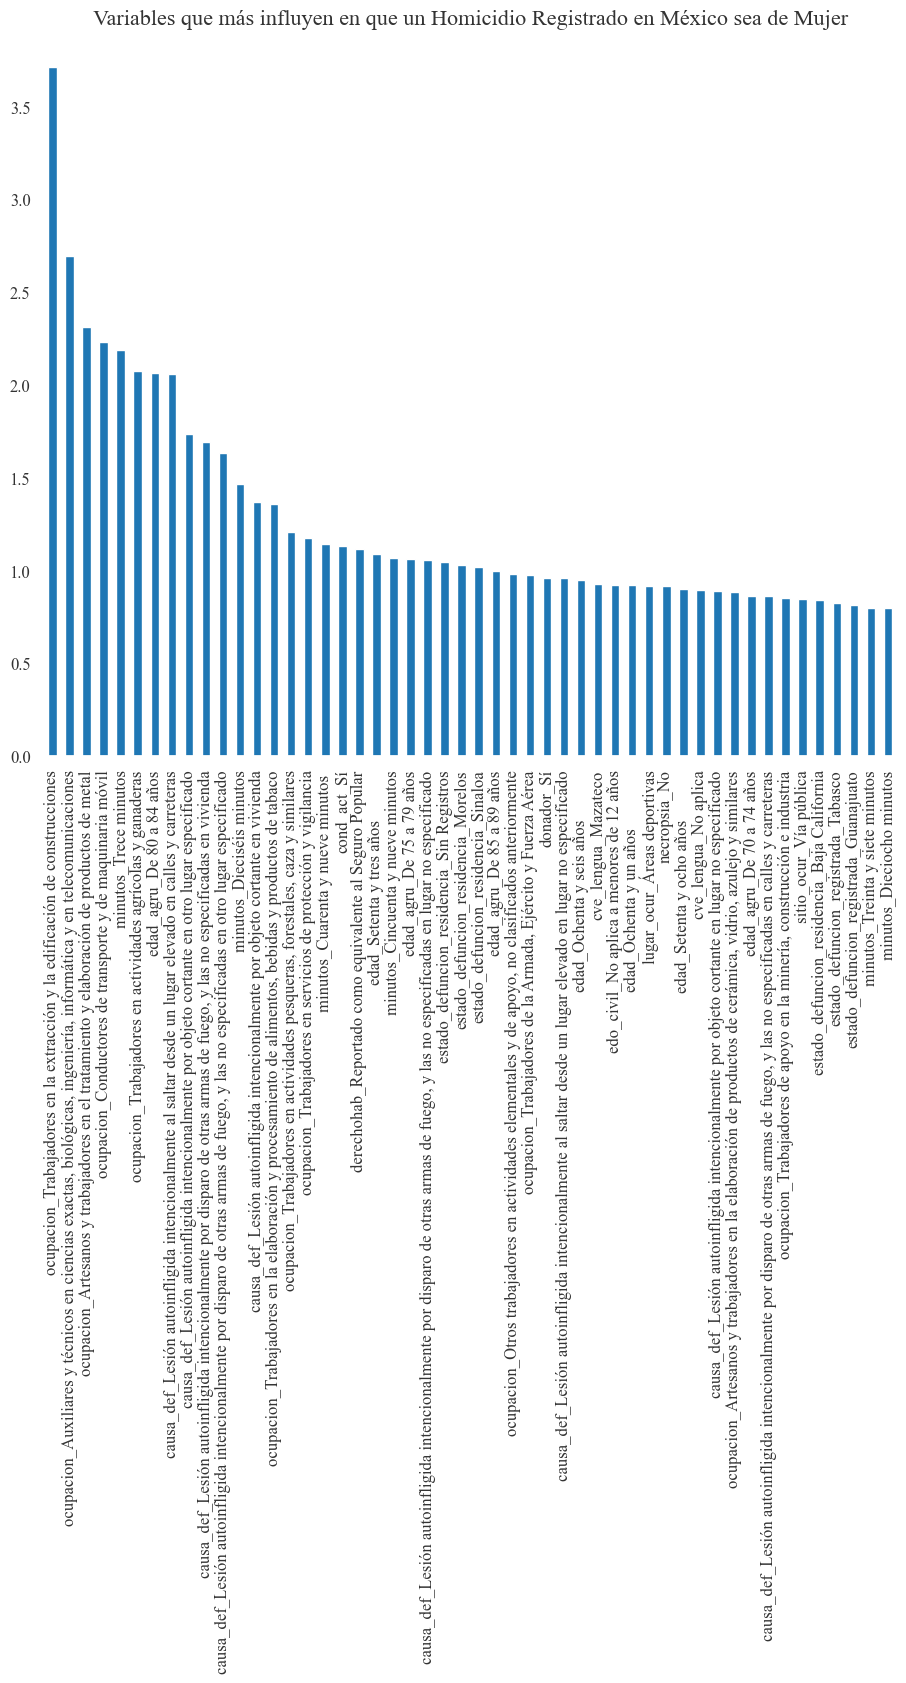

In [ ]:
weights = pd.Series(model.coef_[0],
                    index=X.columns.values) 
print(weights.sort_values(ascending=False)[0:50].plot(kind='bar'))
plt.title('Variables que más influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer')

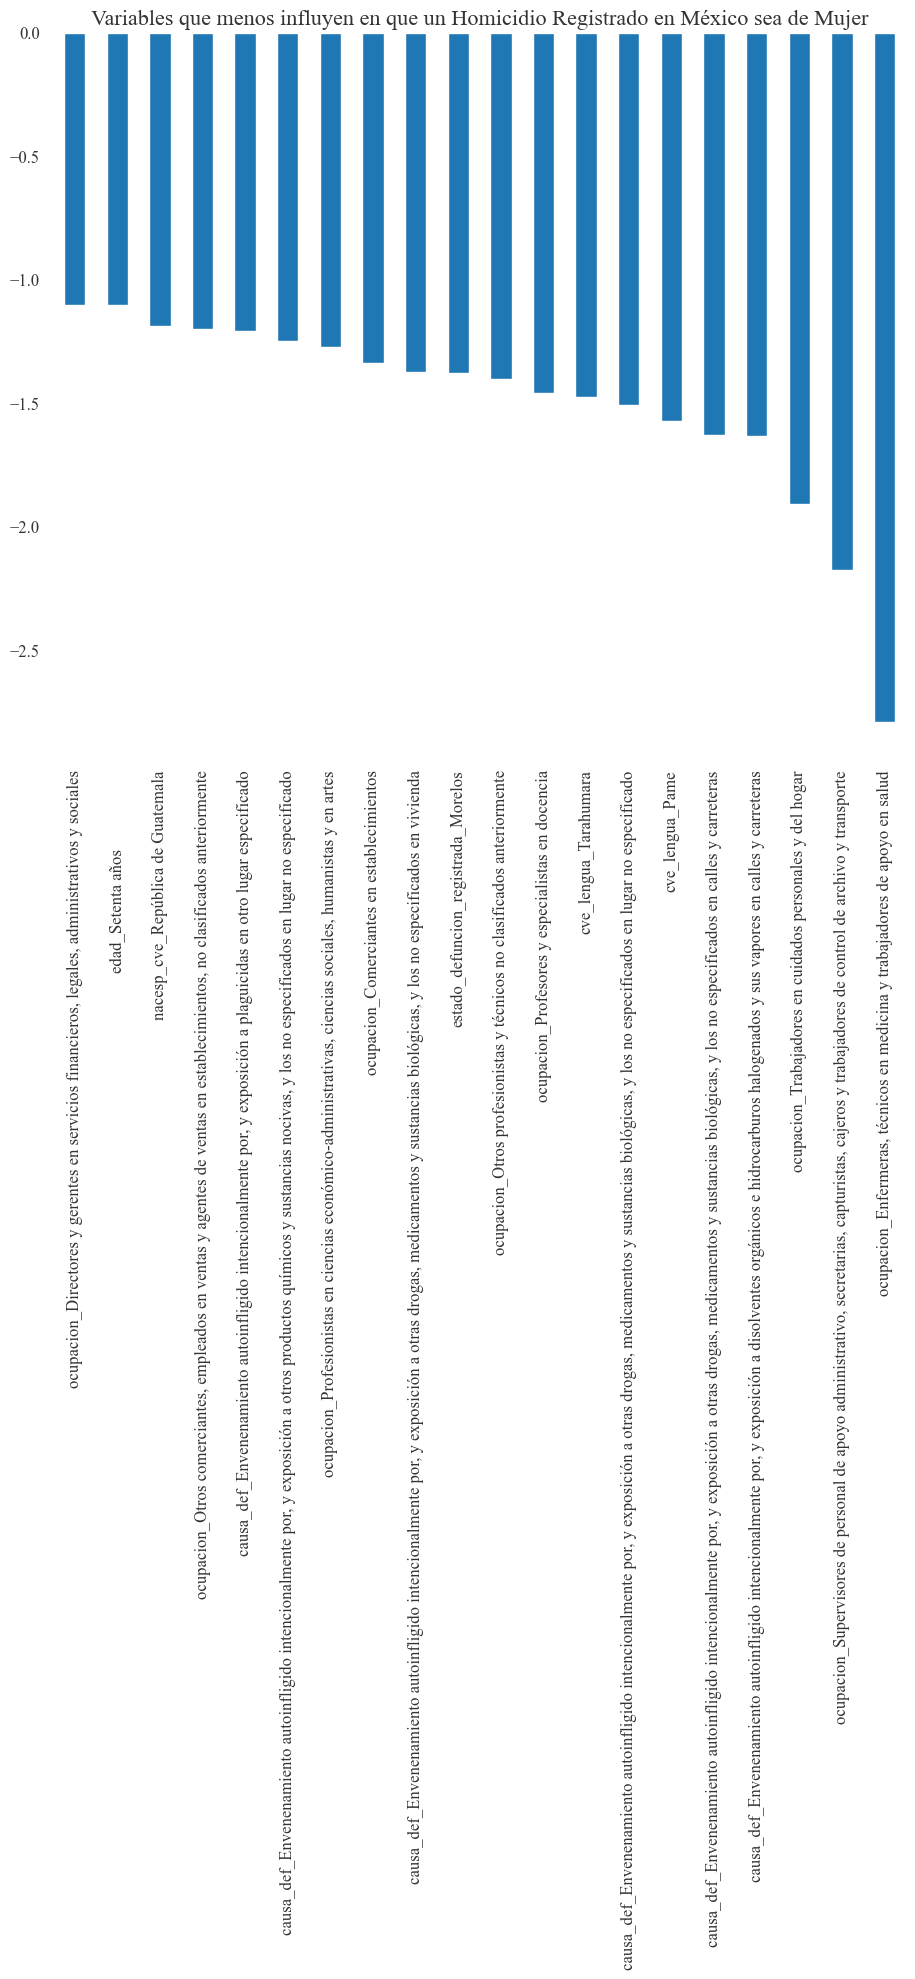

In [ ]:
print(weights.sort_values(ascending=False)[-20:].plot(kind='bar'))
plt.title('Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

## Matriz de Confusión:

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

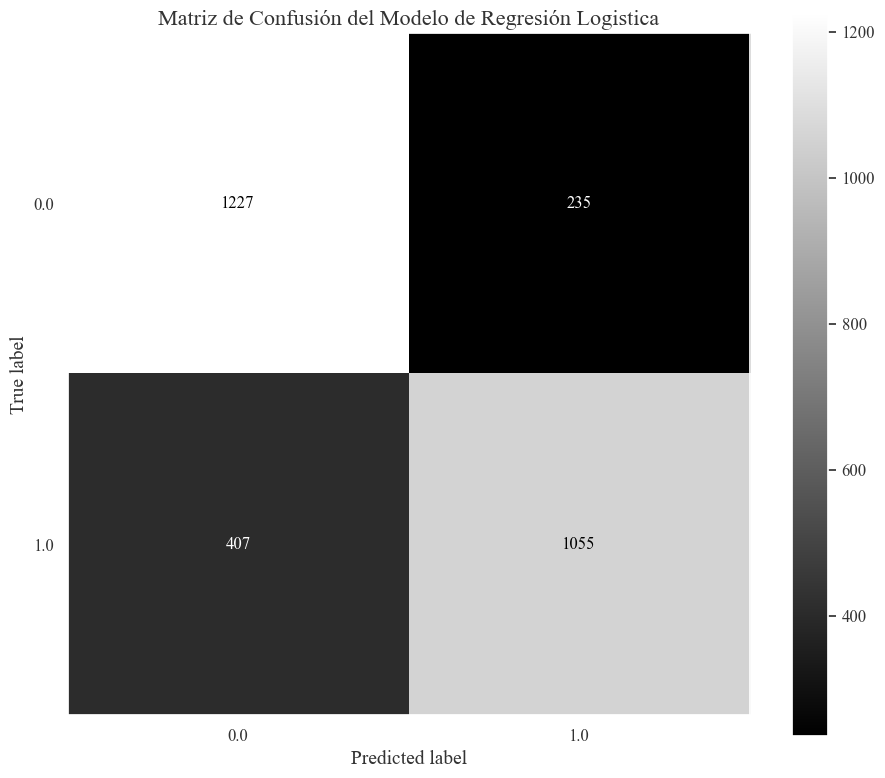

In [ ]:
cm = confusion_matrix(y_test, prediction_test, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot(cmap='gray')
plt.title('Matriz de Confusión del Modelo de Regresión Logistica', size = 16)
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
import numpy as np

## Definimos el Modelo:

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Inicializar validación cruzada estratificada:

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Almacenar resultados:

In [ ]:
accuracy_scores = []
balanced_acc_scores = []
f1_scores = []

for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    
    model.fit(X_train_fold, y_train_fold)
    y_pred_fold = model.predict(X_test_fold)
    
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    balanced_acc_scores.append(balanced_accuracy_score(y_test_fold, y_pred_fold))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold))

## Mostrar resultados promedio:

In [ ]:
print("===== Validación Cruzada (5-fold) =====")
print(f"Accuracy promedio: {np.mean(accuracy_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(balanced_acc_scores):.4f}")
print(f"F1-score promedio: {np.mean(f1_scores):.4f}")

===== Validación Cruzada (5-fold) =====
Accuracy promedio: 0.7767
Balanced Accuracy promedio: 0.7767
F1-score promedio: 0.7615


## Coeficientes:

In [ ]:
feature_names = X.columns 

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\nCoeficientes del Modelo de Regresión Logística:")


Coeficientes del Modelo de Regresión Logística:


In [ ]:
coefficients.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Abs_Coefficient
342,ocupacion_Trabajadores en la extracción y la e...,3.745072,3.745072
302,ocupacion_Auxiliares y técnicos en ciencias ex...,2.731535,2.731535
297,ocupacion_Artesanos y trabajadores en el trata...,2.485743,2.485743
308,ocupacion_Conductores de transporte y de maqui...,2.254526,2.254526
338,ocupacion_Trabajadores en actividades agrícola...,1.999748,1.999748
535,edad_agru_De 80 a 84 años,1.957414,1.957414
96,causa_def_Lesión autoinfligida intencionalment...,1.839986,1.839986
492,minutos_Trece minutos,1.793460,1.793460
116,causa_def_Lesión autoinfligida intencionalment...,1.771625,1.771625
481,minutos_Dieciséis minutos,1.684080,1.684080


## Odds Radio:

In [ ]:
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
print("\nOdds Ratios del Modelo de Regresión Logística:")
print(coefficients[['Feature', 'Odds_Ratio']].sort_values(by='Odds_Ratio', ascending=False))


Odds Ratios del Modelo de Regresión Logística:
                                               Feature  Odds_Ratio
342  ocupacion_Trabajadores en la extracción y la e...   42.312053
302  ocupacion_Auxiliares y técnicos en ciencias ex...   15.356448
297  ocupacion_Artesanos y trabajadores en el trata...   12.010038
308  ocupacion_Conductores de transporte y de maqui...    9.530771
338  ocupacion_Trabajadores en actividades agrícola...    7.387194
..                                                 ...         ...
600                estado_defuncion_registrada_Morelos    0.183645
36   causa_def_Envenenamiento autoinfligido intenci...    0.156525
331  ocupacion_Supervisores de personal de apoyo ad...    0.156309
501                     minutos_Treinta y tres minutos    0.125404
314  ocupacion_Enfermeras, técnicos en medicina y t...    0.107139

[650 rows x 2 columns]


In [ ]:
coefficients.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
342,ocupacion_Trabajadores en la extracción y la e...,3.745072,3.745072,42.312053
302,ocupacion_Auxiliares y técnicos en ciencias ex...,2.731535,2.731535,15.356448
297,ocupacion_Artesanos y trabajadores en el trata...,2.485743,2.485743,12.010038
308,ocupacion_Conductores de transporte y de maqui...,2.254526,2.254526,9.530771
338,ocupacion_Trabajadores en actividades agrícola...,1.999748,1.999748,7.387194
535,edad_agru_De 80 a 84 años,1.957414,1.957414,7.080994
96,causa_def_Lesión autoinfligida intencionalment...,1.839986,1.839986,6.296448
492,minutos_Trece minutos,1.793460,1.793460,6.010213
116,causa_def_Lesión autoinfligida intencionalment...,1.771625,1.771625,5.880404
481,minutos_Dieciséis minutos,1.684080,1.684080,5.387494


In [ ]:
data['estado_defuncion_residencia'].value_counts()

estado_defuncion_residencia
México                 1172
Jalisco                 721
Guanajuato              557
Chihuahua               553
Ciudad de México        400
Puebla                  376
Nuevo León              365
Michoacán               351
Veracruz                349
Yucatán                 341
Coahuila                313
Sonora                  272
Chiapas                 243
San Luis Potosí         243
Oaxaca                  229
Querétaro               224
Tamaulipas              210
Hidalgo                 203
Baja California         191
Quintana Roo            183
Sinaloa                 179
Sin Registros           179
Tabasco                 178
Durango                 168
Aguascalientes          149
Morelos                 146
Zacatecas               110
Campeche                 94
Nayarit                  94
Tlaxcala                 82
Guerrero                 75
Baja California Sur      70
Colima                   50
Name: count, dtype: int64